In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlb
from sklearn.datasets import make_blobs

In [2]:
#設置五個質心
bolb_centers=np.array(
    [[0.2, 2.3],
    [-1.5, 2.3],
    [-2.8, 1.8],
    [-2.8, 2.8],
    [-2.8, 1.3]])
#設定五個標準差
bolb_std=np.array([0.4,0.3,0.1,0.1,0.1])

In [4]:
#依照前面條件生成samples
X,y=make_blobs(n_samples=3000, centers= bolb_centers, cluster_std= bolb_std,random_state=7)

In [11]:
def plotcluster(X, y=None):
    plt.scatter(X[:,0],X[:,1],c=y,s=1)
    plt.xlabel('x_1',fontsize=14)
    plt.ylabel('x_2',fontsize=14,rotation=0)

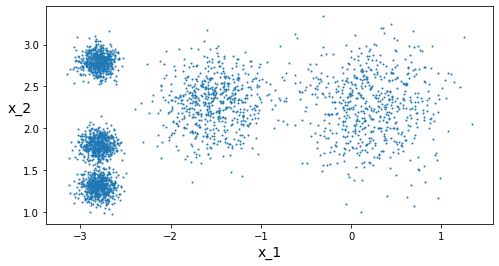

In [12]:
plt.figure(figsize=(8,4))
plotcluster(X)
plt.show()

In [14]:
from sklearn.cluster import KMeans

In [16]:
#共分五群 
kmeans = KMeans(n_clusters=5, random_state=6)
y_pred=kmeans.fit_predict(X)

In [17]:
y_pred

array([3, 0, 1, ..., 0, 1, 4], dtype=int32)

In [18]:
y_pred is kmeans.labels_ #非監督式學習不是label，而是代表分到第幾群ㄣ

True

In [19]:
kmeans.cluster_centers_ 

array([[-2.79677997,  1.29919782],
       [ 0.22500304,  2.25673558],
       [-2.79649097,  2.79379883],
       [-1.50062392,  2.30454441],
       [-2.79484676,  1.802974  ]])

In [20]:
#硬分群：分到第幾群
X_new=np.array([[0,2],[3,2],[-3,3],[-3,2.5]])
kmeans.predict(X_new)

array([1, 1, 2, 2], dtype=int32)

In [21]:
#軟分群 離質心的距離
kmeans.transform(X_new)

array([[2.88324503, 0.34137886, 2.90697064, 1.53121503, 2.80178294],
       [5.83898808, 2.78684791, 5.85059177, 4.51091598, 5.79819525],
       [1.71290001, 3.30954478, 0.28971512, 1.65281187, 1.21447895],
       [1.21787694, 3.23416484, 0.35739849, 1.512062  , 0.72659005]])

In [22]:
kmeans.inertia_ #inertia代表每個點到質心的距離加總

320.47583513978486

In [23]:
X_dist=kmeans.transform(X)
np.sum(X_dist[np.arange(len(X_dist)),kmeans.labels_]**2) 

320.4758351397862

In [25]:
#要分幾群，k最佳解，用inertia衡量
kmeans_per_k=[KMeans(n_clusters=k,random_state=6).fit(X)
             for k in range(1,10)]
inertias=[model.inertia_ for model in kmeans_per_k]

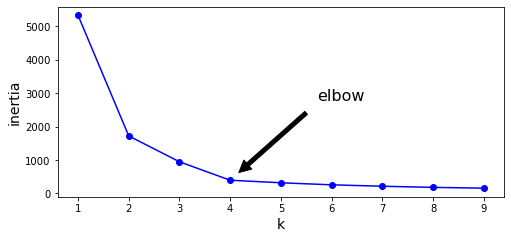

In [27]:
#inertia 並非越小越好，畢竟分越多群肯定越小，這邊分四群，跟三群有明顯差距
plt.figure(figsize=(8,3.5))
plt.plot(range(1,10),inertias,"bo-")
plt.xlabel('k',fontsize=14)
plt.ylabel('inertia',fontsize=14)
plt.annotate('elbow',
            xy=(4,inertias[3]),
            xytext=(0.55,0.55),
            textcoords='figure fraction',
            fontsize=16,
            arrowprops=dict(facecolor='black',shrink=0.1)
            )
plt.axis=([1,9,0,1500])
plt.show()

In [28]:
#dbscan分割蛋黃區 區分高密度區 低密度區
from sklearn.datasets import make_moons

In [34]:
X,y=make_moons(n_samples=1000,noise=0.05,random_state=8) #生成雙月樣本

In [35]:
from sklearn.cluster import DBSCAN

In [36]:
dbscan=DBSCAN(eps=0.05,min_samples=5) #高密度區設0.05
dbscan.fit(X)

DBSCAN(eps=0.05)

In [37]:
dbscan.labels_[:20] #前20分群結果

array([0, 1, 3, 1, 1, 2, 3, 2, 0, 2, 4, 3, 3, 8, 1, 2, 5, 2, 6, 7])

In [38]:
len(dbscan.core_sample_indices_) 
#812筆資料被分到高密度區

812

In [39]:
dbscan.core_sample_indices_[:10] #前十筆核心區指標

array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10])

In [40]:
dbscan.components_[:3] 

array([[ 1.8259979 ,  0.027005  ],
       [-0.05066036,  1.03297812],
       [-0.5152729 ,  0.92671895]])

In [41]:
dbscan2=DBSCAN(eps=0.2) #改設高密度區設0.2
dbscan2.fit(X)

DBSCAN(eps=0.2)

In [42]:
from sklearn.neighbors import KNeighborsClassifier #dbscan無法預測，改用ＫＮＮ

In [45]:
knn=KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_,dbscan.labels_[dbscan.core_sample_indices_]) #fit x:dbscan_data ,y dbscan分群結果 

KNeighborsClassifier(n_neighbors=50)

In [47]:
X_new=np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]]) #預測新data
knn.predict(X_new)

array([7, 2, 8, 0])

In [48]:
#高斯混合 探測離群值
from sklearn.mixture import GaussianMixture

In [50]:
gm=GaussianMixture(n_components=3,n_init=10,random_state=42) #設定模型 n_components=3 分三組資料
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

In [51]:
gm.weights_ #三個權重

array([0.20221872, 0.20626536, 0.59151592])

In [52]:
gm.means_ #三個mean

array([[-0.74804717,  0.55497753],
       [ 1.73451488, -0.06642304],
       [ 0.49889984,  0.25400656]])

In [53]:
gm.covariances_

array([[[ 0.05260074,  0.05979087],
        [ 0.05979087,  0.08723483]],

       [[ 0.05543487,  0.06244211],
        [ 0.06244211,  0.08643713]],

       [[ 0.17324999, -0.10201863],
        [-0.10201863,  0.28229258]]])

In [56]:
gm.converged_ #是否收斂

True

In [57]:
gm.n_iter_ #迭代17次

17

In [58]:
gm.predict(X) #預測Ｘ結果

array([1, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 0, 1, 1, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 1, 1, 0, 2,
       0, 1, 0, 0, 2, 2, 1, 1, 2, 2, 0, 2, 1, 2, 0, 1, 1, 2, 0, 1, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 1, 1, 2, 1, 2, 0, 2, 2, 2, 2, 1, 2, 2, 0, 2,
       1, 2, 1, 2, 1, 2, 0, 1, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 0, 0, 2, 1, 2, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 0, 0, 1, 2, 0, 2, 2, 2, 0,
       1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 2, 0, 2, 1, 1, 2, 0, 1, 2, 2, 0,
       2, 2, 2, 2, 0, 0, 1, 2, 1, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2,
       1, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 2, 0, 2,
       1, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2,
       1, 2, 0, 2, 2, 2, 2, 1, 1, 0, 1, 0, 2, 1, 2, 1, 2, 2, 2, 1, 0, 2,
       1, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 0,

In [59]:
X_new,y_new=gm.sample(6) #生成新sample
X_new

array([[-0.99613324,  0.44686806],
       [ 1.80255197, -0.01030322],
       [ 1.32758421, -0.48553382],
       [ 1.80617437,  0.09674084],
       [ 0.50478498, -0.0591015 ],
       [-0.1234413 ,  0.04628491]])

In [60]:
y_new

array([0, 1, 1, 1, 2, 2])

In [61]:
gm.score_samples(X) # density密度 並不是機率

array([ 0.01731563, -2.06654108, -1.68132541, -0.74925558, -2.01542955,
       -1.62044084, -1.65579268, -1.56321513, -0.09744859, -1.74382083,
       -1.48136643, -1.63789854, -1.40086148, -1.83381904, -2.09943368,
       -1.51657203, -1.74751728, -1.64857218, -1.66412005, -2.22029641,
       -1.58846519, -1.65860724, -2.18925038, -1.49937873, -1.71875295,
       -2.78071502, -0.11475061, -0.45682965, -1.5847761 , -1.63968687,
       -1.32032116, -0.18995803, -2.15558296, -1.35473443, -1.96065236,
       -0.09668779, -1.96851629, -1.60070742, -1.61351365, -0.14484121,
       -1.38923908, -0.83355529, -0.17836067, -1.70804455, -0.57578349,
       -0.36246985, -0.6014269 , -0.62638222, -1.39061347, -1.6287548 ,
       -0.66656881, -0.79840456, -1.82672346, -1.66864086, -1.11606339,
       -1.50131216, -1.54336438, -1.68453417, -0.24893962, -0.95083172,
       -2.58264824, -1.5482636 , -0.56643997, -0.86381752, -2.00377303,
       -2.20773113, -1.5754158 , -1.4423344 , -1.42237006, -1.52

In [62]:
density=gm.score_samples(X) 
threshold=np.percentile(density,6) #設6%為離群值，設定閥值
anomaly=X[density<threshold] #找出所有小於閥值得data

In [63]:
anomaly

array([[-1.04586808e+00, -1.48611838e-02],
       [ 1.23151198e+00, -4.00167626e-01],
       [-9.67118877e-01,  6.06535266e-01],
       [-5.29066993e-02,  1.07604649e+00],
       [ 1.93922484e+00,  4.36340431e-01],
       [ 1.29683647e+00, -3.25305897e-01],
       [ 3.65526325e-02, -5.81800240e-02],
       [ 1.96689878e+00, -8.63288746e-02],
       [ 1.93841984e+00,  4.42324722e-01],
       [ 9.70803907e-02,  1.14356706e+00],
       [ 1.15583153e+00, -5.19974938e-01],
       [ 1.19788412e+00, -4.61427351e-01],
       [-9.20141740e-01,  5.76784225e-02],
       [-1.95043814e-01,  8.33776994e-01],
       [-9.71792587e-01, -6.14538470e-02],
       [ 1.04336187e+00,  4.14813215e-01],
       [ 1.09811286e+00, -5.54153803e-01],
       [-1.89112292e-01,  9.99573616e-01],
       [-1.94106552e-01,  9.80099855e-01],
       [-1.59966858e-01,  9.14392617e-01],
       [-1.50430414e-01,  9.84604197e-01],
       [-1.51751935e-01,  9.65133502e-01],
       [-1.14678115e-01,  1.03109109e+00],
       [-2.